In [1]:
import torch

print(f"GPU available:  {torch.cuda.is_available()}")
print(f"GPU name:       {torch.cuda.get_device_name(0)}")
print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA version:   {torch.version.cuda}")

GPU available:  True
GPU name:       NVIDIA RTX 2000 Ada Generation
GPU memory:     17.2 GB
CUDA version:   12.8


In [ ]:
!pip install unsloth trl transformers datasets peft accelerate bitsandbytes boto3 pyarrow -q
print("✅ All packages installed")

In [3]:
import os

# Increase Hugging Face timeout
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "120"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

print("✅ Hugging Face timeout increased")

✅ Hugging Face timeout increased


In [ ]:
!pip install -U huggingface_hub hf_transfer

In [7]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=torch.float16,
    load_in_4bit=True,
)
print(f"✅ Model loaded")
print(f"   Model name:       Llama-3.2-3B-Instruct (4-bit quantized)")
print(f"   Max seq length:   {max_seq_length}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   GPU memory used:  {torch.cuda.memory_allocated() / 1e9:.2f} GB")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: adc99a1b-d03d-434e-b501-cd501d0d063b)')' thrown while requesting HEAD https://huggingface.co/unsloth/Llama-3.2-3B-Instruct-bnb-4bit/resolve/main/config.json
[huggingface_hub.utils._http|WARNING]'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: adc99a1b-d03d-434e-b501-cd501d0d063b)')' thrown while requesting HEAD https://huggingface.co/unsloth/Llama-3.2-3B-Instruct-bnb-4bit/resolve/main/config.json
Retrying in 1s [Retry 1/5].
[huggingface_hub.utils._http|WARNING]Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 73a52852-d51c-4098-b6de-8b3b0b793746)')' thrown while requesting HEAD https://huggingface.co/unsloth/Llama-3.2-3B-Instruct-bnb-4bit/resolve/main/config.json
[huggingface_hub.utils._

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 2000 Ada Generation. Num GPUs = 1. Max memory: 15.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
✅ Model loaded
   Model name:       Llama-3.2-3B-Instruct (4-bit quantized)
   Max seq length:   512
   Total parameters: 1,803,463,680
   GPU memory used:  2.27 GB


In [ ]:
import os

os.environ["AWS_ACCESS_KEY_ID"] = ""
os.environ["AWS_SECRET_ACCESS_KEY"] = ""
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

In [9]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 16,
    lora_dropout   = 0,
    bias           = "none",
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)

model.print_trainable_parameters()
print(f"\n✅ LoRA adapters attached")
print(f"   Rank (r):       16")
print(f"   Alpha:          16")
print(f"   Target modules: q, k, v, o, gate, up, down projections")
print(f"   Dropout:        0")

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511

✅ LoRA adapters attached
   Rank (r):       16
   Alpha:          16
   Target modules: q, k, v, o, gate, up, down projections
   Dropout:        0


In [10]:
import boto3

BUCKET = "25tvtm-cisc886-bucket-cloud-project"
REGION = "us-east-1"

# Uses AWS credentials already configured in the environment / Colab secrets / aws configure.
# Do not hard-code AWS access keys in the notebook.
session = boto3.Session(region_name=REGION)
s3 = session.client("s3")

try:
    s3.head_bucket(Bucket=BUCKET)
    print("✅ Connected")
except Exception as e:
    print(f"❌ {e}")


✅ Connected


In [11]:
!pip install s3fs pyarrow -q

In [12]:
import pandas as pd
from io import BytesIO
from datasets import Dataset

BUCKET = '25tvtm-cisc886-bucket-cloud-project'
# s3 is already defined from your connection cell above

def load_parquet_sample(prefix, max_files=5):
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)
    files = [
        obj['Key'] for obj in response.get('Contents', [])
        if obj['Key'].endswith('.parquet')
    ][:max_files]

    dfs = []
    for key in files:
        obj = s3.get_object(Bucket=BUCKET, Key=key)
        dfs.append(pd.read_parquet(BytesIO(obj['Body'].read())))
        print(f"  Loaded {key.split('/')[-1]} — {len(dfs[-1]):,} rows")

    return pd.concat(dfs, ignore_index=True)

print("Loading training data...")
train_df = load_parquet_sample('processed/train/', max_files=5)

print("\nLoading validation data...")
val_df = load_parquet_sample('processed/val/', max_files=2)

print(f"\n{'='*40}")
print(f"✅ Data loaded")
print(f"   Train rows: {len(train_df):,}")
print(f"   Val rows:   {len(val_df):,}")

Loading training data...
  Loaded part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 136,895 rows
  Loaded part-00001-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 138,076 rows
  Loaded part-00002-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 149,068 rows
  Loaded part-00003-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 125,656 rows
  Loaded part-00004-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 133,154 rows

Loading validation data...
  Loaded part-00000-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet — 16,575 rows
  Loaded part-00001-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet — 16,535 rows

✅ Data loaded
   Train rows: 682,849
   Val rows:   33,110


In [13]:
from datasets import Dataset

# Keep full loaded data for reporting/statistics
train_df_full = train_df.copy()
val_df_full = val_df.copy()

TRAIN_SAMPLE_SIZE = 50_000
VAL_SAMPLE_SIZE = 5_000

train_df_sample = train_df_full[["prompt", "response"]].dropna().sample(
    n=min(TRAIN_SAMPLE_SIZE, len(train_df_full)),
    random_state=42
).reset_index(drop=True)

val_df_sample = val_df_full[["prompt", "response"]].dropna().sample(
    n=min(VAL_SAMPLE_SIZE, len(val_df_full)),
    random_state=42
).reset_index(drop=True)

def format_prompt(row):
    return {
        "text": f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a helpful beauty and personal care product assistant trained on Amazon reviews.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
{row['prompt']}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
{row['response']}<|eot_id|>"""
    }


train_data = Dataset.from_pandas(train_df_sample)
val_data = Dataset.from_pandas(val_df_sample)

train_data = train_data.map(format_prompt)
val_data = val_data.map(format_prompt)

# Keep only the final text column for training
train_data = train_data.remove_columns(
    [col for col in train_data.column_names if col != "text"]
)

val_data = val_data.remove_columns(
    [col for col in val_data.column_names if col != "text"]
)

print("✅ Data formatted")
print(f"   Train samples: {len(train_data):,}")
print(f"   Val samples:   {len(val_data):,}")
print("\nSample formatted prompt (first 300 chars):")
print(train_data[0]["text"][:300])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Data formatted
   Train samples: 50,000
   Val samples:   5,000

Sample formatted prompt (first 300 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a helpful beauty and personal care product assistant trained on Amazon reviews.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
A customer reviewed a beauty and personal care product with ID B00DP3DJX4 and gave it 5.0 out of 5 st


In [14]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import os
import torch
import torch._dynamo

os.environ["TORCHDYNAMO_DISABLE"] = "1"
torch._dynamo.config.disable = True
torch.cuda.empty_cache()

model.config.use_cache = False

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

MAX_LENGTH = 512

def tokenize_fn(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

print("Tokenizing train...")
train_tok = train_data.map(
    tokenize_fn,
    batched=True,
    remove_columns=train_data.column_names,
    num_proc=1,
)

print("Tokenizing val...")
val_tok = val_data.map(
    tokenize_fn,
    batched=True,
    remove_columns=val_data.column_names,
    num_proc=1,
)

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

args = TrainingArguments(
    output_dir="./outputs",

    # 50k samples / effective batch 8 = 6,250 steps per full epoch
    # 1,000 steps = about 0.16 epoch
    max_steps=1000,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,

    warmup_steps=50,
    learning_rate=2e-4,
    weight_decay=0.01,

    fp16=True,
    bf16=False,

    logging_steps=25,

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    optim="adamw_8bit",
    seed=42,
    report_to="none",
    dataloader_num_workers=0,
    torch_compile=False,
    gradient_checkpointing=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=collator,
)

effective_batch_size = args.per_device_train_batch_size * args.gradient_accumulation_steps
steps_per_epoch = len(train_tok) // effective_batch_size
approx_epochs = args.max_steps / steps_per_epoch

print("✅ Trainer configured")
print(f"   Train: {len(train_tok):,} | Val: {len(val_tok):,}")
print(f"   Max length: {MAX_LENGTH}")
print(f"   Max steps: {args.max_steps:,}")
print(f"   Batch size: {args.per_device_train_batch_size}")
print(f"   Grad accum: {args.gradient_accumulation_steps}")
print(f"   Effective batch size: {effective_batch_size}")
print(f"   Steps per full epoch: {steps_per_epoch:,}")
print(f"   Approx epochs: {approx_epochs:.2f}")
print(f"   Eval every: {args.eval_steps} steps")
print(f"   Save every: {args.save_steps} steps")
print(f"   FP16: {args.fp16} | BF16: {args.bf16}")

Tokenizing train...


Map (num_proc=1):   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizing val...


Map (num_proc=1):   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Trainer configured
   Train: 50,000 | Val: 5,000
   Max length: 512
   Max steps: 1,000
   Batch size: 2
   Grad accum: 4
   Effective batch size: 8
   Steps per full epoch: 6,250
   Approx epochs: 0.16
   Eval every: 250 steps
   Save every: 500 steps
   FP16: True | BF16: False


In [15]:
print("Starting training...")
print("=" * 50)

trainer_stats = trainer.train()

print("=" * 50)
print("✅ Training complete")
print(f"   Total steps:  {trainer_stats.global_step}")
print(f"   Final loss:   {trainer_stats.training_loss:.4f}")
print(f"   Total time:   {trainer_stats.metrics['train_runtime']:.0f} seconds")

Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
250,1.550400,1.474690
500,1.624300,1.469938
750,1.564000,1.465170
1000,1.554400,1.464434


✅ Training complete
   Total steps:  1000
   Final loss:   1.7001
   Total time:   3213 seconds


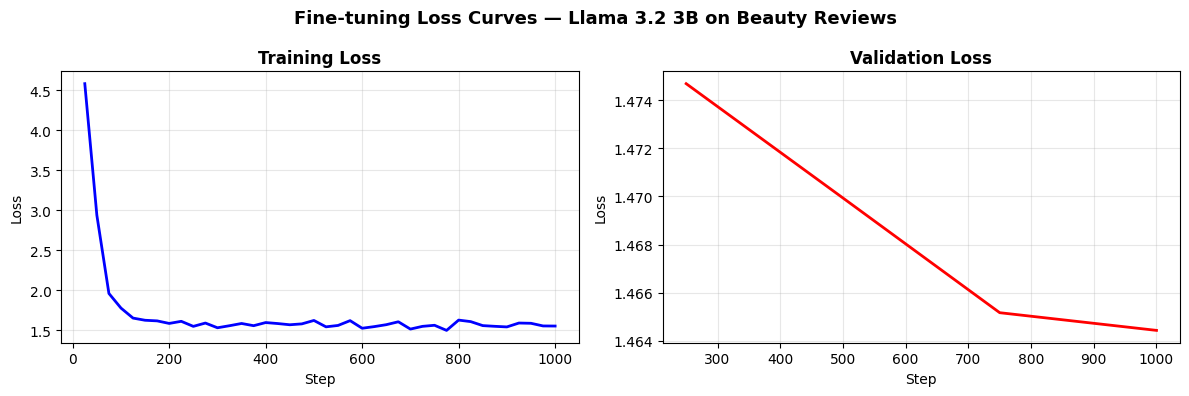

✅ Loss curve saved


In [16]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot([x['step'] for x in train_logs],
         [x['loss'] for x in train_logs], 'b-', linewidth=2)
ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot([x['step'] for x in eval_logs],
         [x['eval_loss'] for x in eval_logs], 'r-', linewidth=2)
ax2.set_title('Validation Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Loss Curves — Llama 3.2 3B on Beauty Reviews',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve saved")

In [17]:
log_history = trainer.state.log_history
eval_logs   = [x for x in log_history if 'eval_loss' in x]

print("✅ Evaluation results from training:")
for entry in eval_logs:
    print(f"   Step {entry['step']:>3} — eval_loss: {entry['eval_loss']:.4f}")

final_eval = eval_logs[-1]
print(f"\n   Final eval loss:    {final_eval['eval_loss']:.4f}")
print(f"   Final eval runtime: {final_eval.get('eval_runtime', 'N/A')}")

✅ Evaluation results from training:
   Step 250 — eval_loss: 1.4747
   Step 500 — eval_loss: 1.4699
   Step 750 — eval_loss: 1.4652
   Step 1000 — eval_loss: 1.4644

   Final eval loss:    1.4644
   Final eval runtime: 422.1093


In [20]:
from pathlib import Path
import os
import glob

# Dynamic local project directory
PROJECT_DIR = Path.cwd()

# Dynamic model names/paths
MODEL_EXPORT_NAME = "cisc886-model"
MODEL_DIR = PROJECT_DIR / MODEL_EXPORT_NAME
GGUF_DIR = PROJECT_DIR / f"{MODEL_EXPORT_NAME}_gguf"

print("Saving model to GGUF format...")
print("=" * 60)
print(f"Project directory: {PROJECT_DIR}")
print(f"HF merged model directory: {MODEL_DIR}")
print(f"GGUF output directory: {GGUF_DIR}")
print("=" * 60)

model.save_pretrained_gguf(
    str(MODEL_DIR),
    tokenizer,
    quantization_method="q4_k_m"
)

# Find GGUF files dynamically
gguf_files = sorted(GGUF_DIR.glob("*.gguf"))

print("\n✅ GGUF files created:")
if not gguf_files:
    print("No GGUF files found in expected directory.")
    print("Searching project directory recursively...")
    gguf_files = sorted(PROJECT_DIR.rglob("*.gguf"))

for file_path in gguf_files:
    size_gb = file_path.stat().st_size / 1e9
    print(f"   {file_path}: {size_gb:.2f} GB")

# Find Modelfile dynamically
modelfile_path = GGUF_DIR / "Modelfile"

if modelfile_path.exists():
    print("\n✅ Ollama Modelfile:")
    print(f"   {modelfile_path}")

    print("\nOllama create command:")
    print(f"ollama create cisc886-beauty-assistant -f {modelfile_path}")
else:
    print("\n⚠️ Modelfile not found in expected GGUF directory.")

Saving model to GGUF format...
Project directory: /workspace/project
HF merged model directory: /workspace/project/cisc886-model
GGUF output directory: /workspace/project/cisc886-model_gguf
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:00<00:00, 928.15it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:20<00:00, 70.01s/it] 


Unsloth: Merge process complete. Saved to `/workspace/project/cisc886-model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/workspace/project/cisc886-model_gguf/Llama-3.2-3B-Instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/workspace/project/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_

In [21]:
from pathlib import Path
import os
import boto3

# Dynamic project directory based on current notebook location
PROJECT_DIR = Path.cwd()

# Dynamic GGUF directory
MODEL_EXPORT_NAME = "cisc886-model"
GGUF_DIR = PROJECT_DIR / f"{MODEL_EXPORT_NAME}_gguf"

print("Searching for GGUF files...")
print(f"Expected GGUF directory: {GGUF_DIR}")

# First search expected directory
gguf_files = sorted(GGUF_DIR.glob("*.gguf"))

# Fallback: search recursively in project directory
if not gguf_files:
    print("No GGUF files found in expected directory. Searching recursively...")
    gguf_files = sorted(PROJECT_DIR.rglob("*.gguf"))

if not gguf_files:
    raise FileNotFoundError("No GGUF files found. Make sure save_pretrained_gguf finished successfully.")

print(f"Found GGUF files: {[str(f) for f in gguf_files]}")

# Prefer quantized Q4_K_M file if available
q4_files = [f for f in gguf_files if "Q4_K_M" in f.name.upper()]
gguf_path = q4_files[0] if q4_files else gguf_files[0]

file_size = gguf_path.stat().st_size / 1e9

print(f"Selected GGUF file: {gguf_path}")
print(f"Size: {file_size:.2f} GB")

Searching for GGUF files...
Expected GGUF directory: /workspace/project/cisc886-model_gguf
Found GGUF files: ['/workspace/project/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf']
Selected GGUF file: /workspace/project/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf
Size: 2.02 GB


In [23]:
from pathlib import Path
import os
import boto3

BUCKET = "25tvtm-cisc886-bucket-cloud-project"
MODEL_KEY = "model/cisc886-beauty-model.gguf"

# Use gguf_path from previous cell if it exists, otherwise find it dynamically
if "gguf_path" not in globals():
    PROJECT_DIR = Path.cwd()
    MODEL_EXPORT_NAME = "cisc886-model"
    GGUF_DIR = PROJECT_DIR / f"{MODEL_EXPORT_NAME}_gguf"

    gguf_files = sorted(GGUF_DIR.glob("*.gguf"))

    if not gguf_files:
        gguf_files = sorted(PROJECT_DIR.rglob("*.gguf"))

    if not gguf_files:
        raise FileNotFoundError("No GGUF file found. Run the GGUF export cell first.")

    q4_files = [f for f in gguf_files if "Q4_K_M" in f.name.upper()]
    gguf_path = q4_files[0] if q4_files else gguf_files[0]

gguf_path = Path(gguf_path)

if not gguf_path.exists():
    raise FileNotFoundError(f"GGUF file not found: {gguf_path}")

s3 = boto3.Session(
    region_name="us-east-1"
).client("s3")

total = gguf_path.stat().st_size
uploaded = [0]

def progress(chunk):
    uploaded[0] += chunk
    pct = uploaded[0] / total * 100
    print(
        f"\rUploading... {pct:.1f}% "
        f"({uploaded[0] / 1e9:.2f}/{total / 1e9:.2f} GB)",
        end=""
    )

print(f"Selected GGUF file: {gguf_path}")
print(f"File size: {total / 1e9:.2f} GB")
print(f"Uploading to: s3://{BUCKET}/{MODEL_KEY}")

s3.upload_file(
    str(gguf_path),
    BUCKET,
    MODEL_KEY,
    Callback=progress
)

print(f"\n✅ Upload complete → s3://{BUCKET}/{MODEL_KEY}")

Selected GGUF file: /workspace/project/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf
File size: 2.02 GB
Uploading to: s3://25tvtm-cisc886-bucket-cloud-project/model/cisc886-beauty-model.gguf
Uploading... 100.0% (2.02/2.02 GB)
✅ Upload complete → s3://25tvtm-cisc886-bucket-cloud-project/model/cisc886-beauty-model.gguf


In [25]:
# ============================================================
# Clean Hyperparameter Table for Section 5 — Model Fine-Tuning
# Keeps only the important report fields.
# ============================================================

import sys
import math
import torch
import pandas as pd
import importlib.metadata as importlib_metadata

def get_package_version(package_name):
    try:
        return importlib_metadata.version(package_name)
    except Exception:
        return "Unavailable"

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    trainable_percent = 100 * trainable_params / total_params
    return total_params, trainable_params, trainable_percent

def get_lora_config(model):
    lora_values = {
        "LoRA r": "N/A",
        "LoRA alpha": "N/A",
        "LoRA dropout": "N/A",
        "LoRA target modules": "N/A",
    }

    peft_config = getattr(model, "peft_config", None)

    if peft_config:
        adapter_name = list(peft_config.keys())[0]
        cfg = peft_config[adapter_name]

        lora_values["LoRA r"] = getattr(cfg, "r", "N/A")
        lora_values["LoRA alpha"] = getattr(cfg, "lora_alpha", "N/A")
        lora_values["LoRA dropout"] = getattr(cfg, "lora_dropout", "N/A")

        target_modules = getattr(cfg, "target_modules", "N/A")
        if isinstance(target_modules, (list, set, tuple)):
            target_modules = ", ".join(sorted(list(target_modules)))
        lora_values["LoRA target modules"] = target_modules

    return lora_values

args = trainer.args

# Core training values
train_dataset_size = len(trainer.train_dataset)
per_device_batch_size = args.per_device_train_batch_size
gradient_accumulation_steps = args.gradient_accumulation_steps
effective_batch_size = per_device_batch_size * gradient_accumulation_steps

steps_per_epoch = math.ceil(train_dataset_size / effective_batch_size)

if args.max_steps and args.max_steps > 0:
    training_steps = args.max_steps
    effective_epochs = round(training_steps / steps_per_epoch, 4)
else:
    training_steps = int(steps_per_epoch * args.num_train_epochs)
    effective_epochs = args.num_train_epochs

completed_steps = trainer.state.global_step
completed_epochs = (
    round(completed_steps / steps_per_epoch, 4)
    if completed_steps and completed_steps > 0
    else "Training not run yet"
)

total_params, trainable_params, trainable_percent = count_parameters(model)

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"
gpu_memory_gb = (
    round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
    if torch.cuda.is_available()
    else "N/A"
)

lora_config = get_lora_config(model)

# Clean report table
report_rows = [
    ("Base model", getattr(model, "name_or_path", "N/A")),
    ("Fine-tuning library", "Unsloth + Hugging Face Transformers + PEFT"),
    ("Fine-tuning technique", "QLoRA / LoRA adapter fine-tuning"),
    ("Training dataset size", train_dataset_size),
    ("Validation dataset size", len(trainer.eval_dataset)),
    ("Training control", "max_steps" if args.max_steps and args.max_steps > 0 else "num_train_epochs"),
    ("Training steps", training_steps),
    ("Steps per full epoch", steps_per_epoch),
    ("Effective epochs trained", effective_epochs),
    ("Completed steps", completed_steps),
    ("Completed effective epochs", completed_epochs),
    ("Per-device batch size", per_device_batch_size),
    ("Gradient accumulation steps", gradient_accumulation_steps),
    ("Effective batch size", effective_batch_size),
    ("Learning rate", args.learning_rate),
    ("Warmup steps", args.warmup_steps),
    ("Weight decay", args.weight_decay),
    ("Optimizer", str(args.optim)),
    ("Precision", "fp16" if args.fp16 else "bf16" if args.bf16 else "fp32"),
    ("Max sequence length", MAX_LENGTH if "MAX_LENGTH" in globals() else "N/A"),
    ("LoRA r", lora_config["LoRA r"]),
    ("LoRA alpha", lora_config["LoRA alpha"]),
    ("LoRA dropout", lora_config["LoRA dropout"]),
    ("LoRA target modules", lora_config["LoRA target modules"]),
    ("Total model parameters", total_params),
    ("Trainable parameters", trainable_params),
    ("Trainable parameter %", round(trainable_percent, 4)),
    ("GPU", gpu_name),
    ("GPU memory GB", gpu_memory_gb),
]

hyperparam_df = pd.DataFrame(report_rows, columns=["Report Field", "Value"])

display(hyperparam_df)

hyperparam_df.to_csv("clean_hyperparameters.csv", index=False)

with open("clean_hyperparameters.md", "w", encoding="utf-8") as f:
    f.write(hyperparam_df.to_markdown(index=False))

epoch_sentence = (
    f"The fine-tuning run used {train_dataset_size:,} training examples with an effective batch size "
    f"of {effective_batch_size}. One full epoch required {steps_per_epoch:,} optimization steps. "
    f"The run used {training_steps:,} training steps, corresponding to approximately "
    f"{effective_epochs} effective epochs."
)

print(epoch_sentence)

with open("epoch_statement.txt", "w", encoding="utf-8") as f:
    f.write(epoch_sentence)



,Report Field,Value
0,Base model,unsloth/Llama-3.2-3B-Instruct-bnb-4bit
1,Fine-tuning library,Unsloth + Hugging Face Transformers + PEFT
2,Fine-tuning technique,QLoRA / LoRA adapter fine-tuning
3,Training dataset size,50000
4,Validation dataset size,5000
5,Training control,max_steps
6,Training steps,1000
7,Steps per full epoch,6250
8,Effective epochs trained,0.16
9,Completed steps,1000


The fine-tuning run used 50,000 training examples with an effective batch size of 8. One full epoch required 6,250 optimization steps. The run used 1,000 training steps, corresponding to approximately 0.16 effective epochs.
